In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import FASHION_MNIST_NAMES, SYNTH_NAMES
from experiments import KMeansExperiment
#plot params
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

LIST_SEED = [42, 123, 456, 789, 101112]
MAX_ITER = 100
K = 10
store = KMeansExperiment()

# K-Means Clustering: Final Evaluation

This notebook evaluates a custom K-Means implementation across two datasets: **Fashion MNIST** and a **Synthetic dataset**. We analyze convergence, cluster assignments, inertia, and overall accuracy across multiple random seeds to test the stability of the algorithm.

## Fashion MNIST dataset

### K-means

In [2]:
for seed in LIST_SEED:
    store.run_experiment("kmeans_simple", "fashion_mnist", k=K, max_iter=MAX_ITER, seed=seed)
    res = store.results["kmeans_simple"]["fashion_mnist"][seed]
    print(f"Seed {seed:6} | Acc: {res['accuracy']:.3f} | Inertia: {res['inertia']:.1f}")

Converged after 29 iterations.
Seed     42 | Acc: 0.483 | Inertia: 31788.1
Converged after 11 iterations.
Seed    123 | Acc: 0.523 | Inertia: 31154.7
Converged after 31 iterations.
Seed    456 | Acc: 0.522 | Inertia: 31800.2
Converged after 22 iterations.
Seed    789 | Acc: 0.572 | Inertia: 29122.5
Converged after 11 iterations.
Seed 101112 | Acc: 0.536 | Inertia: 31903.7


In [3]:
seed = 42
res = store.results["kmeans_simple"]["fashion_mnist"][seed]
X = res["x_projected"] if "x_projected" in res else res["x_original"]

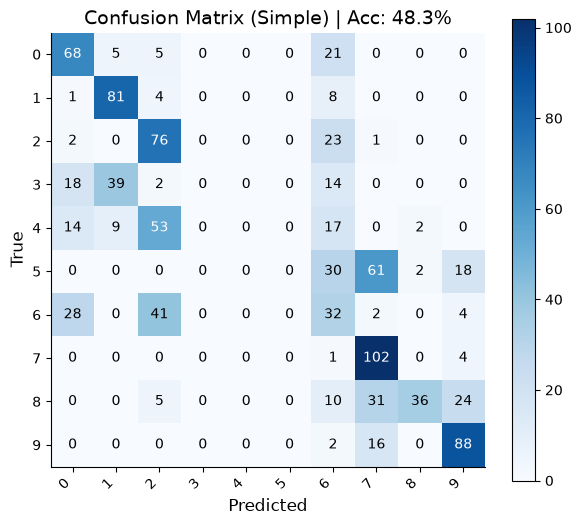

In [5]:
cm = pd.crosstab(pd.Series(res["y"]), pd.Series(res["y_mapped"])).reindex(index=np.arange(10), columns=np.arange(10), fill_value=0)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(np.arange(10)); ax.set_xticklabels(FASHION_MNIST_NAMES, rotation=45, ha="right")
ax.set_yticks(np.arange(10)); ax.set_yticklabels(FASHION_MNIST_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm.values[i, j], ha="center", va="center", color="white" if cm.values[i, j] > cm.values.max()/2 else "black")
plt.colorbar(im); plt.title(f"Confusion Matrix (Simple) | Acc: {res['accuracy']:.1%}"); plt.show()

### K-means++

### Inertia and Variability

## Synthetic dataset

### K-means

### K-means++

### Inertia and Variability